In [1]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Plot of the phylogenetic tree reconstruction for Dengue 2 -  Genotype Asian-American Lineage D.2

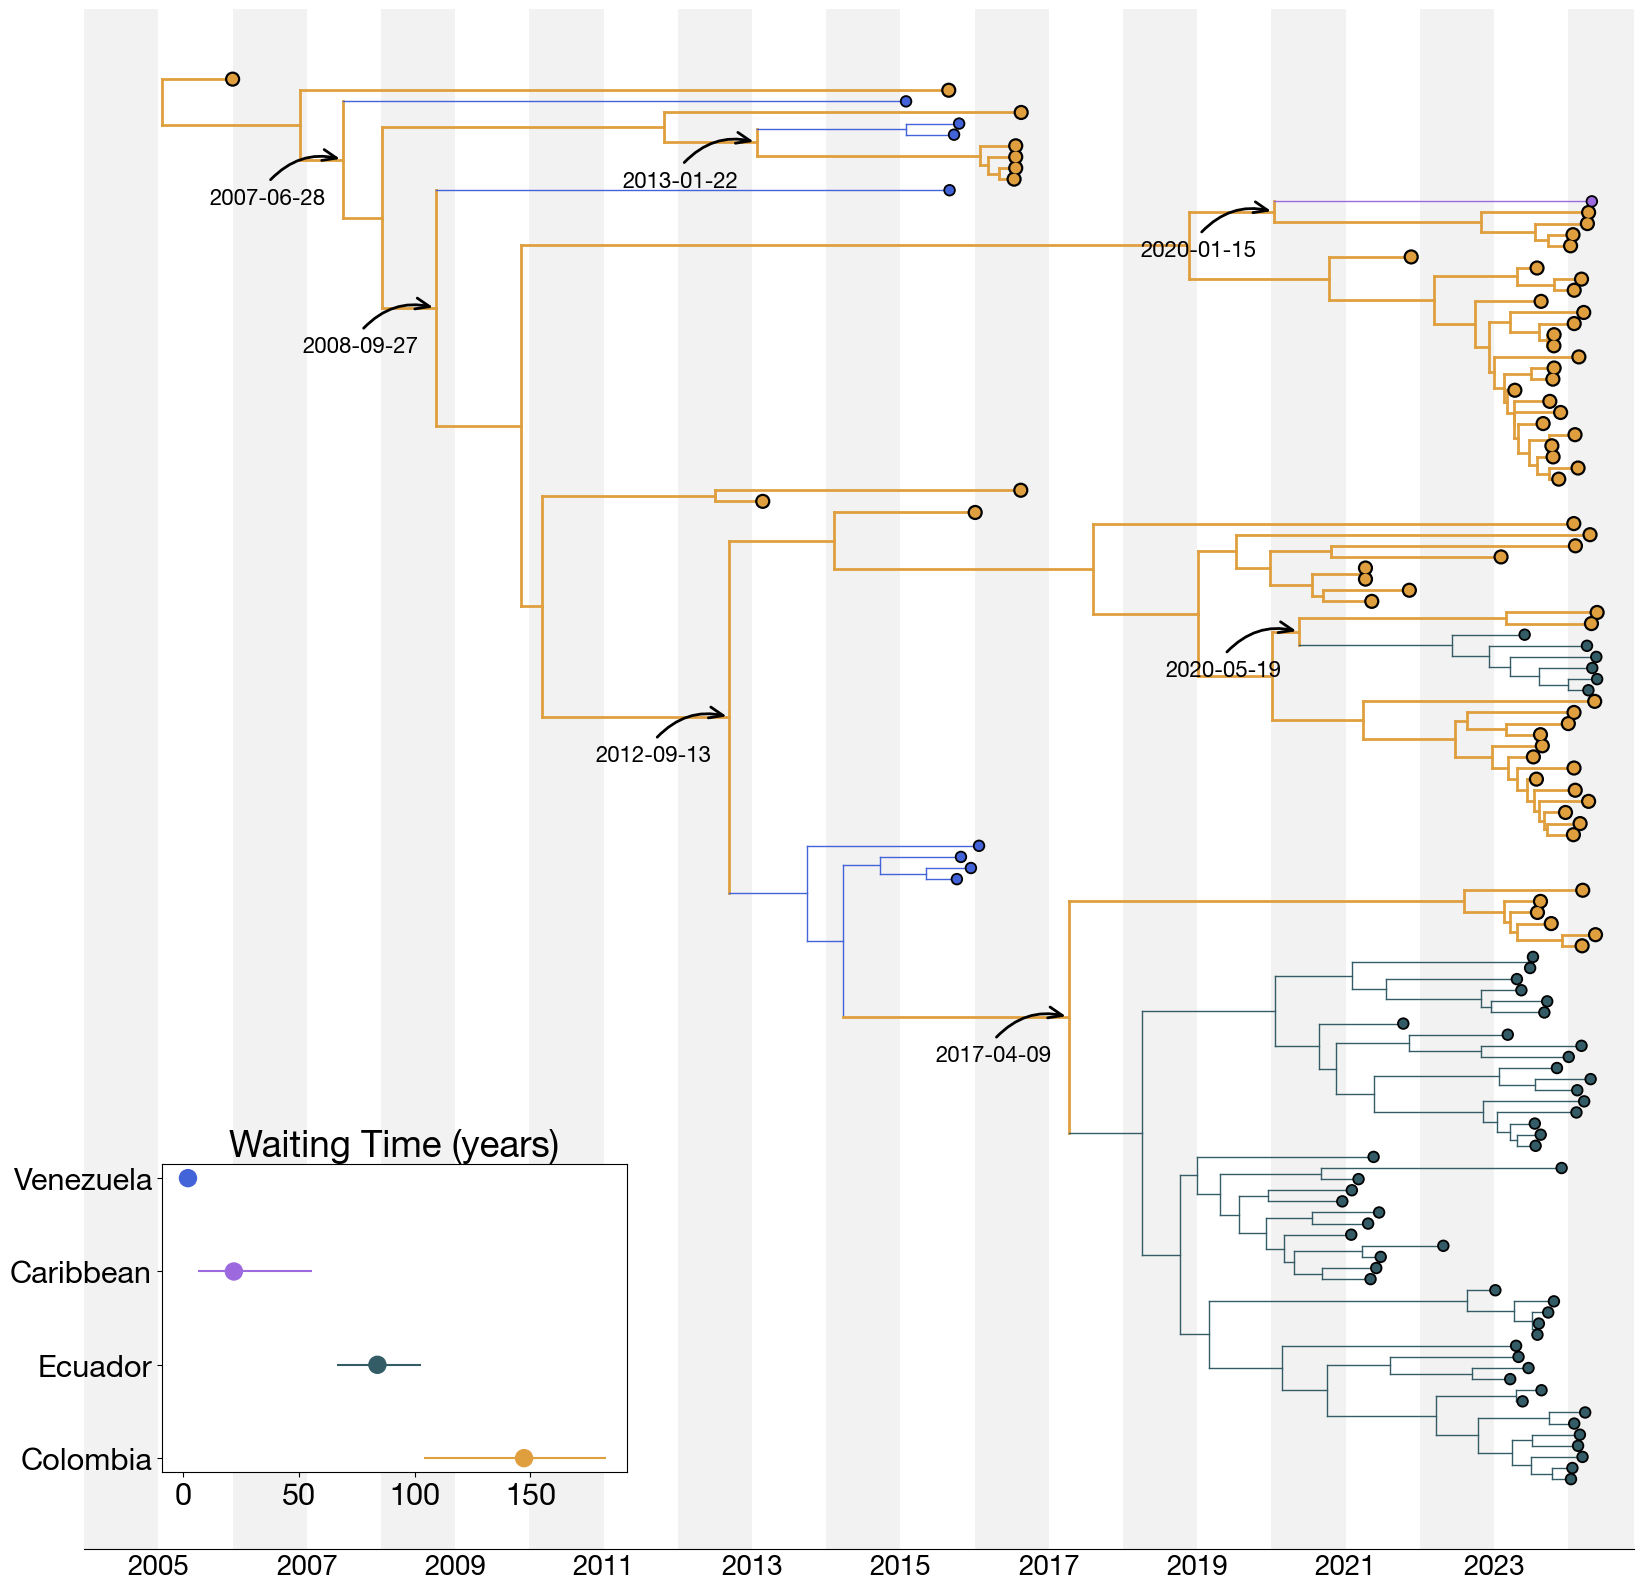

In [5]:
import baltic as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

# Load the tree
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/D2_D2/subsampled_D2lin_markov.aligned.mcc.tree'
ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

# Define color and label dictionaries
colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Function to detect introductions into Colombia
def introductions_into_colombia(k):
    return 'location.rate' in k.traits and k.traits['location.rate'] == 'Colombia'

def introductions_from_colombia(k):
    return 'location.rate' in k.traits and k.traits['location.rate'] != 'Colombia'

# Function to plot a curved arrow pointing to a node
def plot_curved_arrow(ax, start_x, start_y, end_x, end_y):
    arrow = FancyArrowPatch((start_x, start_y), (end_x, end_y), 
                            connectionstyle="arc3,rad=-0.3",  # Creates a curve
                            color='black', 
                            arrowstyle='->,head_length=10,head_width=4', lw=2, zorder = 1000)
    ax.add_patch(arrow)

# Function to get the coordinates for arrowhead at the node (introduction)


# Function to get the parent node coordinates (arrow start)
def get_parent_coordinates(node):
    parent = node.parent
    return parent.absoluteTime, parent.y

def other_coordinate(node):
    parent = node.parent
    return parent.absoluteTime -0.5, parent.y -0.5

# Visualization parameters
c_func = lambda k: colors[k.traits['location.rate']] if 'location.rate' in k.traits and k.traits['location.rate'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location.rate'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location.rate'] == 'Colombia' else 1

# Create the figure
fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Plot the tree
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

# Add curved arrows for introductions into Colombia, with annotation of time
for node in ll.Objects:
    if introductions_from_colombia(node) and node.parent and node.parent.traits['location.rate'] == 'Colombia':
        # Get coordinates for arrow start and end
        end_x, end_y = get_parent_coordinates(node)
        start_x, start_y = other_coordinate(node)
        start_x = start_x - 0.5
        start_y = start_y - 1.5
        
        # Plot curved arrow
        plot_curved_arrow(ax, start_x, start_y, end_x, end_y)
        
        # Annotate the time of introduction (absoluteTime) next to the arrow
        introduction_time = decimal_year_to_date(round(node.parent.absoluteTime, 2))
        introduction_time = introduction_time.strftime('%Y-%m-%d')
        ax.text(start_x - 0.8, start_y - 2, f'{introduction_time}', fontsize=16, color='black', ha='left', zorder = 1001)

# Add trunk rewards inset
axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2])

# Create dataframe for rewards
data = [{'state': 'Colombia', 'median_reward': 147.272, 'HPD95Hi_reward': 182.4485, 'HPD95Lo_reward': 103.9863},
        {'state': 'Ecuador', 'median_reward': 83.9682, 'HPD95Hi_reward': 102.9849, 'HPD95Lo_reward': 66.7309},
        {'state': 'Caribbean', 'median_reward': 22.0218, 'HPD95Hi_reward': 55.8659, 'HPD95Lo_reward': 6.561},
        {'state': 'Venezuela', 'median_reward': 2.2085, 'HPD95Hi_reward': 4.7152, 'HPD95Lo_reward': 0},
        ]
trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'median_reward'
trunkRewards = trunkRewards.sort_values(by='median_reward', ascending=False).reset_index(drop=True)

# Scatter plot for rewards
y_positions = range(len(trunkRewards))
axins.scatter(trunkRewards['median_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.set_yticks(y_positions)
axins.set_yticklabels(trunkRewards['state'])
axins.set_xlabel('')
axins.set_title('Waiting Time (years)')

# Add aesthetic adjustments
years = np.arange(2005, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
ax.tick_params(axis='x', size=0, labelsize=20)
ax.tick_params(axis='y', size=0, labelsize=0)
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x, x+1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(2004, 2026, 1) if x % 2 == 0]

ax.set_xlim(2004, ll.mostRecent + 0.5)

# Save the figure
resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_D2_D2.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_D2_D2.svg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

# Plot of the Markov Jumps density through time #

In [13]:
#Another decimal2date function
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

#Open Markov Jump file
MarkovJumps = pd.read_table('/Users/ricardorivero/Documents/DENV/2024/D2/D2_D2/DIII_D2_Jumps.csv', sep=',', skiprows=1)

MRSD = ll.mostRecent
tmrca = MRSD - ll.treeHeight
print(MRSD)

def convert_to_date_using_mrsd(x, mrsd):
    return mrsd - x

#Get the date of the jumps
MarkovJumps['time'] = pd.to_numeric(MarkovJumps['time'], errors='coerce')
MarkovJumps['date'] = convert_to_date_using_mrsd(MarkovJumps['time'], MRSD).round(2)
#Remove jumps before the tree height
MarkovJumps = MarkovJumps[MarkovJumps['date'] >= tmrca]
#Convert date to date
MarkovJumps['date'] = MarkovJumps['date'].apply(decimal_year_to_date)
#Format as YMD
MarkovJumps['date'] = MarkovJumps['date'].dt.strftime('%Y-%m-%d')
#convert to datetime
MarkovJumps['date'] = pd.to_datetime(MarkovJumps['date'])

#replace USA with United States
MarkovJumps['from'] = MarkovJumps['from'].str.replace('USA', 'Caribbean')
MarkovJumps['to'] = MarkovJumps['to'].str.replace('USA', 'Caribbean')

print(MarkovJumps)


2024.3907103825136
         state       from         to       time       date
0      1000000   Colombia    Ecuador   4.040169 2020-05-08
1      1000000   Colombia    Ecuador   5.929159 2018-06-17
2      1001000   Colombia    Ecuador   3.783739 2020-08-11
3      1001000   Colombia    Ecuador   6.643443 2017-10-01
4      1002000   Colombia    Ecuador   1.946109 2022-06-10
...        ...        ...        ...        ...        ...
79125  9393000  Caribbean  Venezuela  10.876819 2013-07-06
79126  9612000  Caribbean  Venezuela   9.171196 2015-03-22
79127  9863000  Caribbean  Venezuela   9.681744 2014-09-17
79128  9909000  Caribbean  Venezuela  12.826988 2011-07-24
79129  9997000  Caribbean  Venezuela   8.993794 2015-05-27

[78633 rows x 5 columns]


In [14]:
MarkovJumps.groupby(['from', 'to']).size()

from       to       
Caribbean  Colombia       149
           Ecuador        166
           Venezuela       93
Colombia   Caribbean     8024
           Ecuador      13548
           Venezuela    37549
Ecuador    Caribbean      361
           Colombia      3178
           Venezuela       69
Venezuela  Caribbean      966
           Colombia      9629
           Ecuador       4901
dtype: int64

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


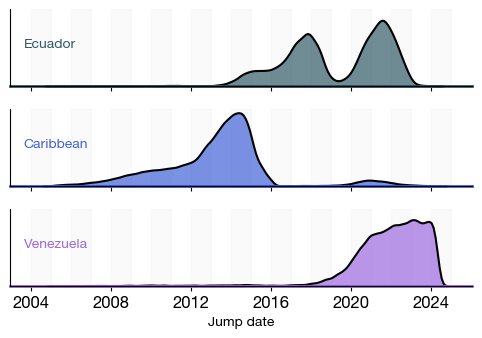

In [20]:
# Density ridgeline plot of the jumps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Same color palette as the tree
colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Country dictionary
country_dict = {
    1: 'Ecuador',
    2: 'Caribbean',
    3: 'Venezuela'
}

# Ensure that 'date' column is in datetime format
MarkovJumps['date'] = pd.to_datetime(MarkovJumps['date'])
#filter out the jumps from Colombia
MarkovJumps = MarkovJumps[MarkovJumps['to'] != 'Colombia']

# Map country names to numerical indices based on their order in the 'from' column in FacetGrid
country_order = MarkovJumps['to'].map(country_dict).unique()
country_to_ypos = {country: idx for idx, country in enumerate(country_order)}

# Create the ridgeline plot
g = sns.FacetGrid(MarkovJumps, row='to', hue='to', aspect=15, height=1, palette=colors)

# Plot the ridgelines
g.map(sns.kdeplot, 'date', clip_on=False, fill=True, alpha=0.7, lw=1.5, bw_adjust=0.5, ec='black')

# Add horizontal lines to each ridge
g.map(plt.axhline, y=0, lw=2, clip_on=False)


# Define the years to shade (every other year)
min_year = MarkovJumps['date'].dt.year.min()
max_year = MarkovJumps['date'].dt.year.max()
years = np.arange(min_year-2, max_year + 2)

# Select every other year starting from the minimum year
if min_year % 2 == 0:
    shade_years = years[::2]  # Even years
else:
    shade_years = years[1::2]  # Odd years

# Add vertical blocks to each subplot
for ax in g.axes.flat:
    for year in shade_years:
        start_date = pd.Timestamp(f'{year}-01-01')
        end_date = pd.Timestamp(f'{year}-12-31')
        ax.axvspan(start_date, end_date, color='lightgrey', alpha=0.1, zorder=0)


# Add labels to each ridge
for i, ax in enumerate(g.axes.flat):
    # Dynamically place the text label based on the max y value of the current axis (ridge)
    y_max = ax.get_ylim()[1]  # Get the maximum y-limit for the current ridge
    x_max = ax.get_xlim()[1]  # Get the maximum x-limit for the current

    # Set the position slightly below the peak of the ridge
    ax.text(x_max * 0.6, y_max * 0.5, country_dict[i+1],
            fontweight='bold', fontsize=10,
            color=ax.lines[-1].get_color())

# Adjust the vertical spacing
g.fig.subplots_adjust(hspace=0.3)

# Remove yticks and spines
g.set_titles("")
g.set(yticks=[])
g.set_yticklabels([])

# This removes the default 'Density' label on the y-axis
g.set_axis_labels("", "")  # Remove y-axis label

# Set figure size
g.fig.set_size_inches(5, 5)
plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
plt.xlabel('Jump date', fontsize=10, fontweight='bold')

# Display the plot
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/Ridgeline_D2_D2.jpeg', dpi=1200, bbox_inches='tight')
plt.show()

In [27]:
#Preprocess markov jumps for map
MarkovJumps_map = pd.read_table('/Users/ricardorivero/Documents/DENV/2024/D2/D2_D2/DIII_D2_Jumps.csv', sep=',', skiprows=1)
#group by "from" country and filter out those with less than 1%
connections_df = MarkovJumps_map.groupby(['from', 'to']).size()
#filter out those with less than 1% of the total number of jumps
connections_df = connections_df[connections_df > 0.01*connections_df.sum()]

connections_df = connections_df.reset_index()
connections_df.columns = ['from', 'to', 'jumps']
connections_df['from'] = connections_df['from'].str.replace('USA', 'Caribbean')
connections_df['to'] = connections_df['to'].str.replace('USA', 'Caribbean')
#create percentage column
connections_df['percentage_movements'] = connections_df['jumps']/connections_df['jumps'].sum()*100
connections_df

#create percentage column




,from,to,jumps,percentage_movements
0,Colombia,Caribbean,8027,10.255002
1,Colombia,Ecuador,13557,17.319927
2,Colombia,Venezuela,37780,48.266346
3,Ecuador,Colombia,3189,4.074150
4,Venezuela,Caribbean,967,1.235404
5,Venezuela,Colombia,9853,12.587832
6,Venezuela,Ecuador,4901,6.261338


['Caribbean' 'Ecuador' 'Venezuela']
Median for Caribbean: 9.0, HPD: (11, 6)
Median for Ecuador: 15.0, HPD: (19, 11)
Median for Venezuela: 43.0, HPD: (50, 29)


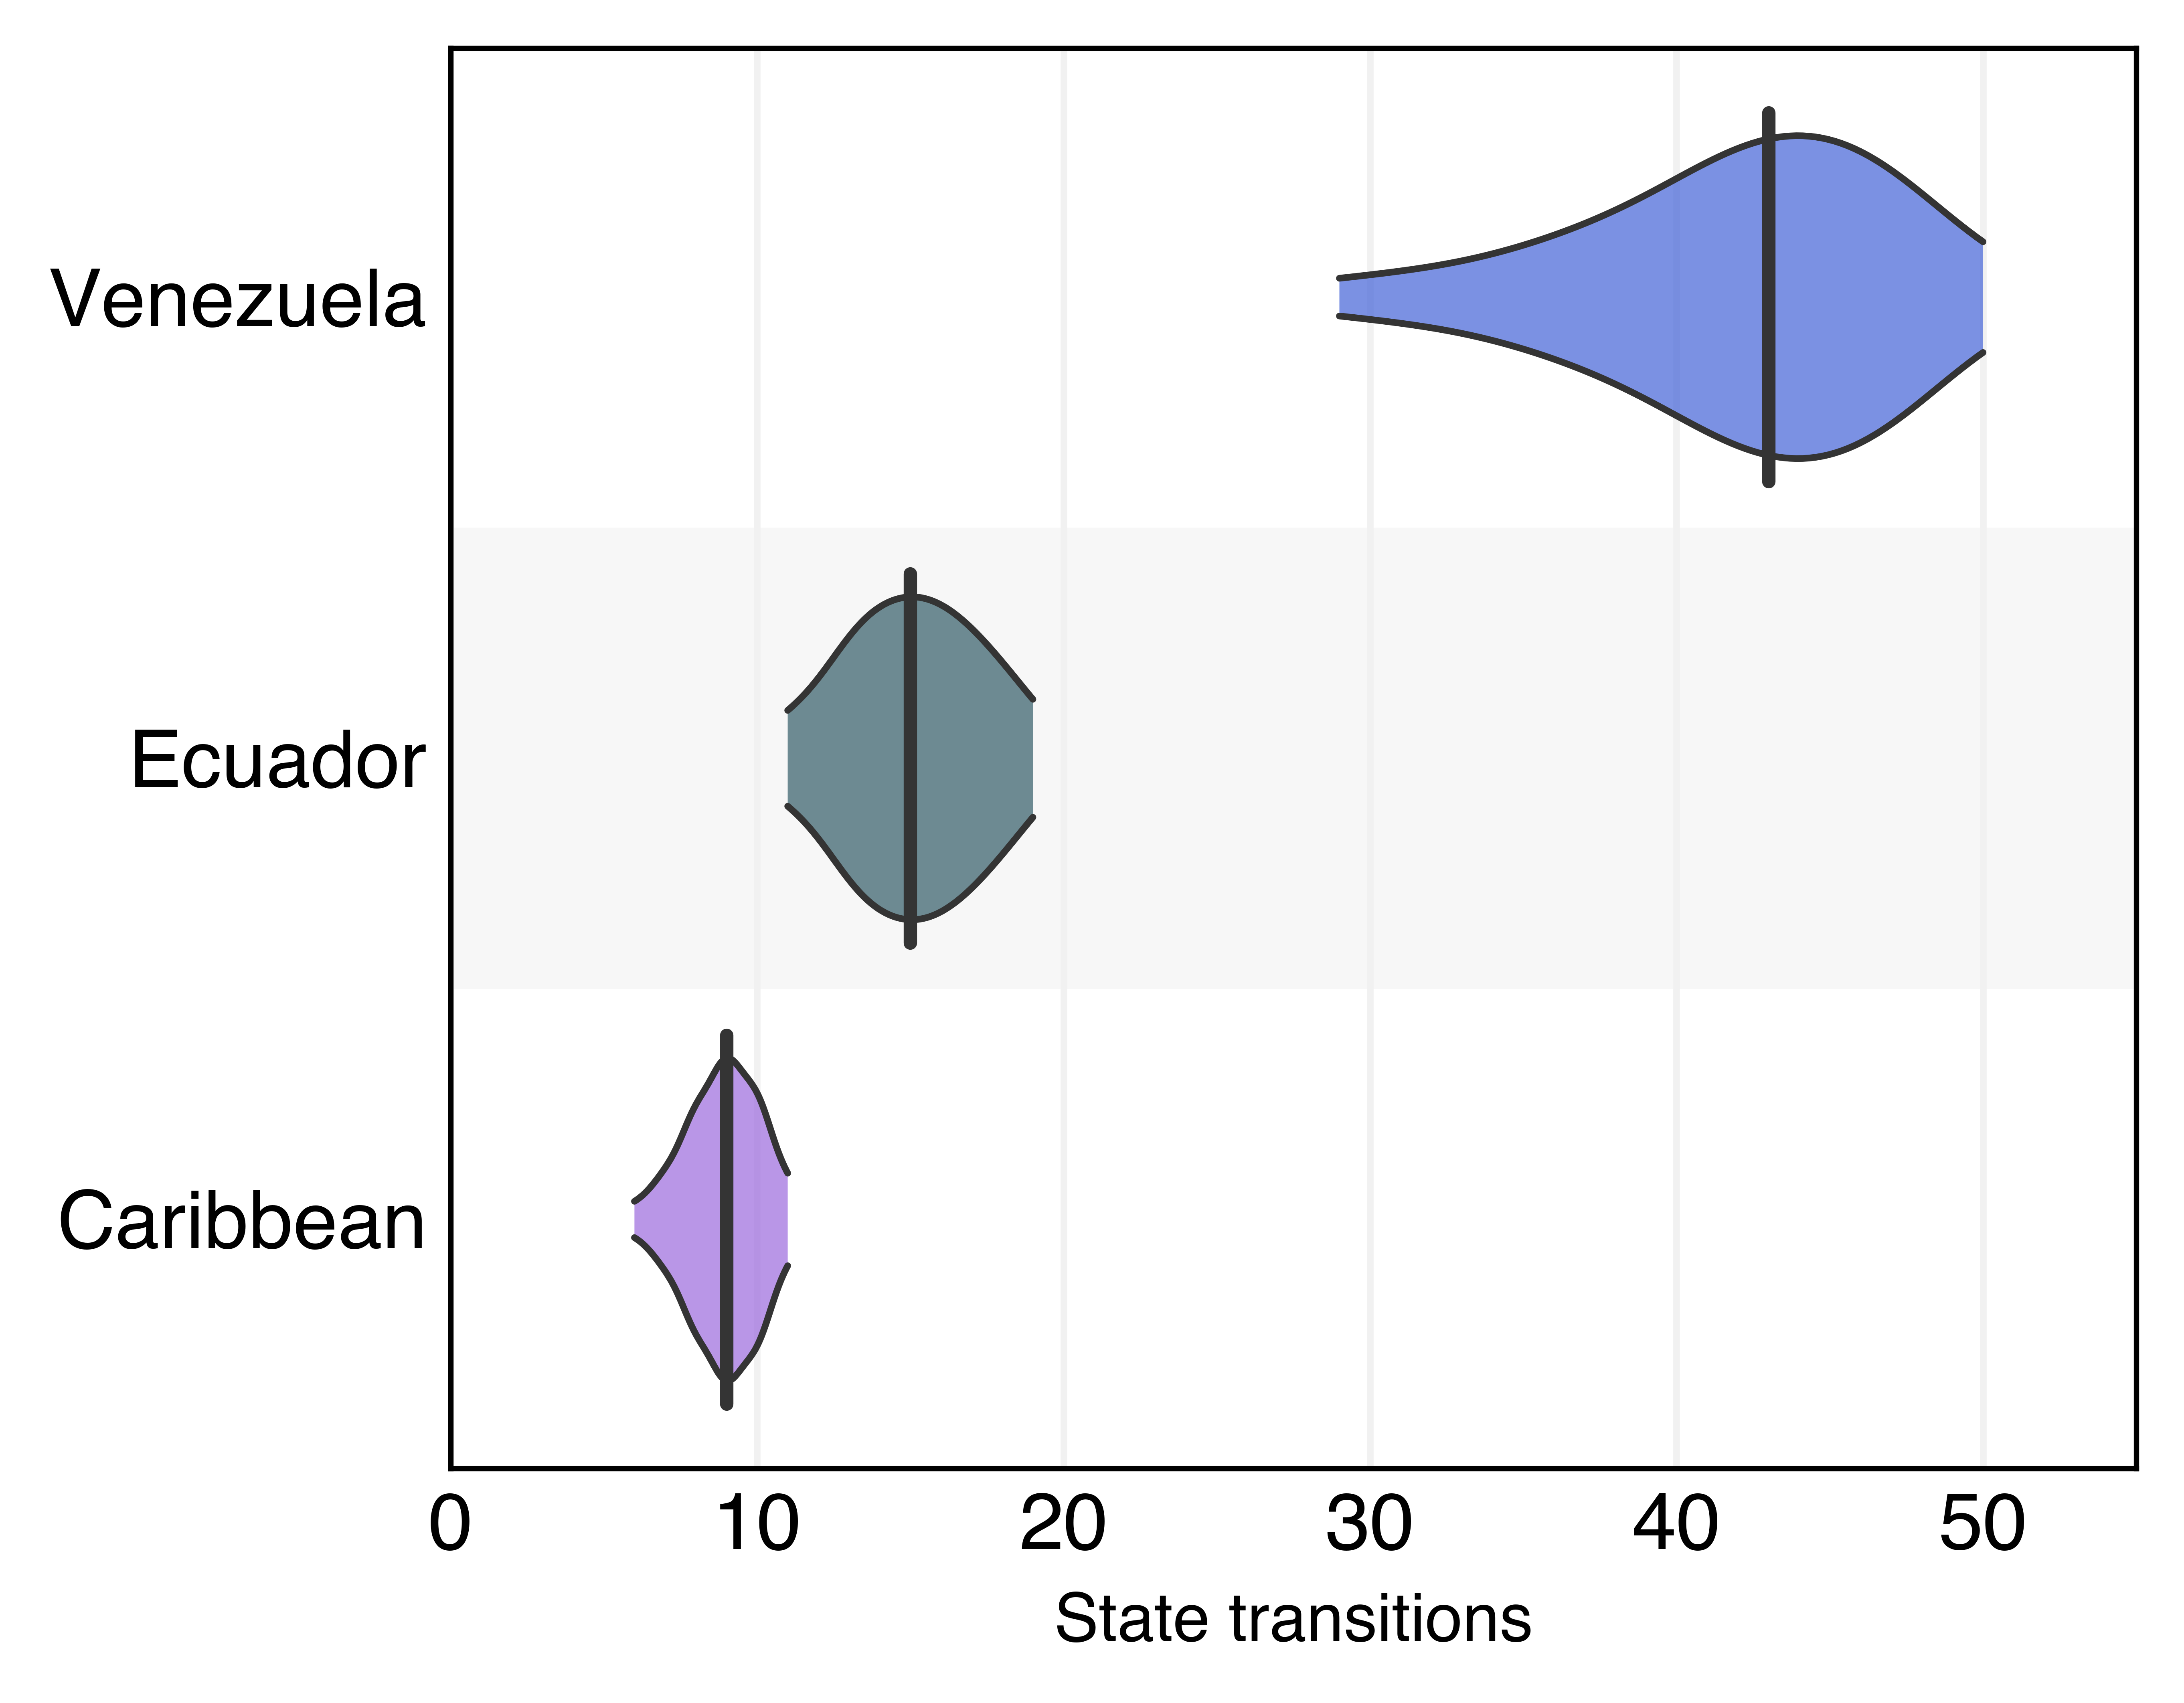

In [41]:
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

color = '#343434'

colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Violin plot of the jumps from Colombia to other countries
location = "Colombia"

# Filter the DataFrame
Colombia_jumps = MarkovJumps.loc[
    (MarkovJumps["from"] == location) | (MarkovJumps["to"] == location)
].copy()

# Correct the assignment to ensure proper alignment
Colombia_jumps.loc[Colombia_jumps["to"] == location, "to"] = Colombia_jumps["from"]
Colombia_jumps["from"] = location

# Convert 'state' to numeric and group the data
Colombia_jumps["state"] = pd.to_numeric(Colombia_jumps["state"], errors='coerce')
Colombia_jumps["state"] = Colombia_jumps["state"].apply(lambda x: int(x / 10000) * 10000)
Colombia_jumps = Colombia_jumps.groupby(["state", "to"])["time"].agg("count").reset_index()

# Remove any NaN or empty strings in 'to' column
Colombia_jumps = Colombia_jumps[Colombia_jumps['to'].notna()]
Colombia_jumps = Colombia_jumps[Colombia_jumps['to'] != '']

print(Colombia_jumps['to'].unique())
# Create the violin plot
def plot_jumps_violin(ax, j):
    grouped = j.groupby("to")['time'].median().sort_values()
    y_labels = grouped.index

    for i, query in enumerate(y_labels):
        data = j.loc[j['to'] == query, 'time'].to_numpy().ravel()
        data = data[~np.isnan(data)]
        if len(data) == 0:
            continue  

        data_median = np.median(data)
        hpdHi, hpdLo = hpd(data, 0.95)
        x_grid = np.linspace(hpdLo, hpdHi, 101)

        kde = gaussian_kde(data, bw_method=0.4)
        y_grid = kde.evaluate(x_grid)
        y_grid = y_grid / y_grid.max() * 0.35

        ax.plot(x_grid, [i + y for y in y_grid], color=color, lw=1, zorder=101, solid_capstyle="round")
        ax.plot(x_grid, [i - y for y in y_grid], color=color, lw=1, zorder=101, solid_capstyle="round")

        ax.fill_between(
            x_grid,
            [i - y for y in y_grid],
            [i + y for y in y_grid],
            facecolor=colors.get(query, color),
            edgecolor='none',
            alpha=0.7,
            zorder=100
        )
        ln = ax.vlines(data_median, i - 0.4, i + 0.4, color=color, linewidth=2, zorder=110)
        print(f"Median for {query}: {data_median}, HPD: ({hpdLo}, {hpdHi})")
        ln.set_capstyle("round")

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    ax.axhspan(0.5, 1.5, color=color, alpha=0.04, edgecolor=None, linewidth=0)

    ax.tick_params(axis="x", bottom=False, which="both", labelbottom=True, labelsize=12, pad=0)
    ax.tick_params(axis="y", left=False, which="both", labelleft=True, labelsize=12, pad=0)
    ax.tick_params(axis="x", bottom=False, which="both", rotation=0, pad=0)

    # Label axes
    ax.set_xlabel("State transitions", fontsize=10)
    ax.set_ylabel("", fontsize=10)
    ax.set_title("")
    ax.set_xlim((0, 55))
    ax.set_facecolor("w")

    # Add a simple grid
    ax.grid(which="both", axis='x', linewidth=1, color="#F1F1F1", zorder=1)

fig, ax = plt.subplots(dpi=1200, figsize=(5, 4))
plot_jumps_violin(ax, Colombia_jumps)
plt.tight_layout()
plt.savefig('../Figures/Violin_D2_D2_fromColombia.jpeg', dpi=1200, bbox_inches='tight')
plt.show()

dict_keys(['name', 'altSpellings', 'area', 'borders', 'callingCodes', 'capital', 'capital_latlng', 'currencies', 'demonym', 'flag', 'geoJSON', 'ISO', 'languages', 'latlng', 'nativeName', 'population', 'provinces', 'region', 'subregion', 'timezones', 'tld', 'translations', 'wiki'])
Unique Regions in Dataset: {'', 'Europe', 'Asia', 'Africa', 'Americas', 'Oceania'}

Countries in the Americas:
Greenland
Montserrat
Panama
Bermuda
South Georgia
Saint Pierre and Miquelon
Brazil
Falkland Islands
Mexico
Dominica
United States
Martinique
Jamaica
Guatemala
Barbados
Suriname
Uruguay
Argentina
Grenada
Guyana
Saint Vincent and the Grenadines
Bolivia
Paraguay
Anguilla
Cayman Islands
Colombia
The Bahamas
Haiti
Canada
Saint Lucia
Cuba
Peru
Costa Rica
Saint Kitts and Nevis
Puerto Rico
Dominican Republic
French Guiana
Venezuela
Belize
Nicaragua
Chile
Guadeloupe
El Salvador
Ecuador
Aruba
Honduras
Antigua and Barbuda
Trinidad and Tobago
0    10.255002
1    17.319927
2    48.266346
3     4.074150
4     1.23

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


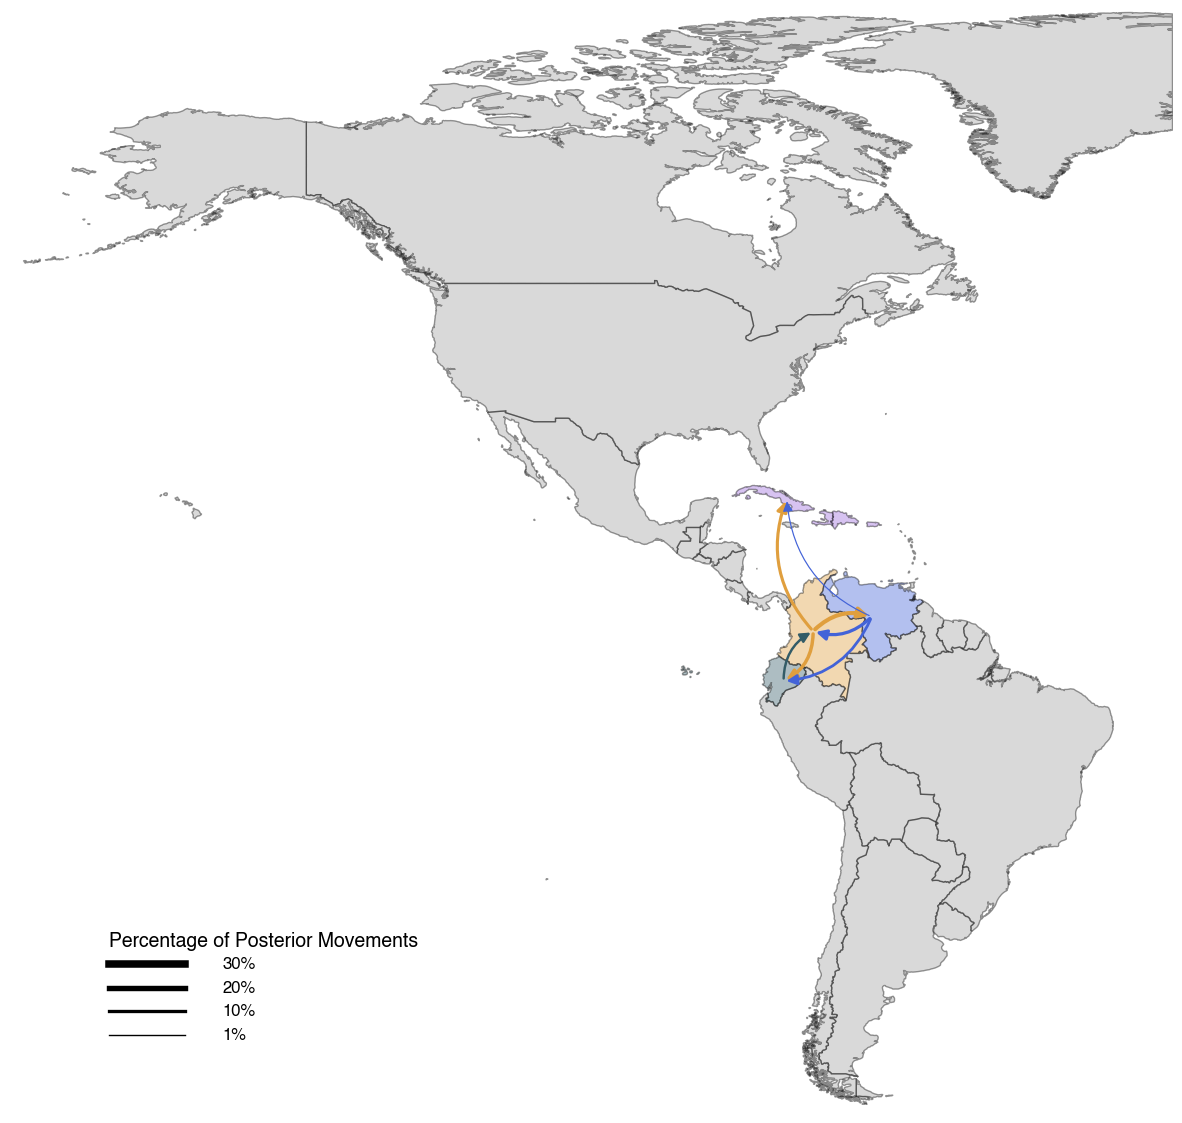

In [37]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cartopy


from countryinfo import CountryInfo

available_countries = CountryInfo().all()
# Define the regions that constitute the Americas
americas_continents = ['North America', 'South America', 'Central America', 'Caribbean']

sample = list(available_countries.values())[0]
print(sample.keys())
# Extract unique continents (optional)
unique_regions = set(
    country['region'] for country in available_countries.values() if 'region' in country
)
print("Unique Regions in Dataset:", unique_regions)

# Filter countries in the Americas and extract their names
americas_regions = ['Americas']  # This is the correct label used by your data

american_countries = [
    country['name'] for country in available_countries.values()
    if country.get('region') in americas_regions
]

print("\nCountries in the Americas:")
for name in american_countries:
    print(name)

# Read the GeoJSON file
world = gpd.read_file('/Users/ricardorivero/Documents/DENV/2024/world-administrative-boundaries.geojson')
world['name'] = world['name'].str.replace('United States of America', 'United States')
world['name'] = world['name'].str.replace('Bolivia (Plurinational State of)', 'Bolivia')
world['name'] = world['name'].str.replace('Venezuela (Bolivarian Republic of)', 'Venezuela')



# Filter for countries in the Americas
America = world[world['name'].isin(american_countries)]

# Define the color palette
palette = {
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade",
    "Cuba": "#9c6ade",
    "Puerto Rico": "#9c6ade",
    "Dominican Republic": "#9c6ade",
    "Haiti": "#9c6ade"
}

# Define the bounding box coordinates
minx, miny = -180, -57
maxx, maxy = -27, 84

# Create the bounding box
bbox = box(minx, miny, maxx, maxy)

# Convert the bounding box to a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs="EPSG:4326")

# Clip the America GeoDataFrame with the bounding box
America_clipped = gpd.clip(America, bbox_gdf)

# Map colors based on country name
America_clipped['color'] = America_clipped['name'].map(palette)

# Handle countries without a specified color
America_clipped['color'] = America_clipped['color'].fillna('#A0A0A0')

# Define country coordinates (longitude, latitude)
country_coords = {
    "Colombia": (-74.2973, 4.5709),
    "Peru": (-75.0152, -9.19),
    "Ecuador": (-78.1834, -1.8312),
    "Caribbean": (-77.781167, 21.52175),
    "Venezuela": (-66.5897, 6.4238)
}

# Read connections from CSV
#Replace USA with United States
MarkovJumps_map = pd.read_table('/Users/ricardorivero/Documents/DENV/2024/D2/D2_D2/DIII_D2_Jumps.csv', sep=',', skiprows=1)
#group by "from" country and filter out those with less than 1%
connections_df = MarkovJumps_map.groupby(['from', 'to']).size()
#filter out those with less than 1% of the total number of jumps
connections_df = connections_df[connections_df > 0.01*connections_df.sum()]

connections_df = connections_df.reset_index()
connections_df.columns = ['from', 'to', 'jumps']
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')
#create percentage column
connections_df['percentage_movements'] = connections_df['jumps']/connections_df['jumps'].sum()*100
print(connections_df['percentage_movements'])


def scale_bayes_factor(x, min_val=1, max_val=20, min_width=3, max_width=350):
    # Normalize x to the [0, 1] range based on the percentage scale (min_val to max_val)
    normalized_x = (x - min_val) / (max_val - min_val)
    
    # Scale the width between min_width and max_width based on the normalized value
    scaled_width = min_width + (normalized_x * (max_width - min_width))
    
    return scaled_width

connections_df['scaled_width'] = connections_df['percentage_movements'].apply(scale_bayes_factor)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.set_facecolor('#e8f1f8')
# Plot the clipped map with the specified colors
#Set function for Alpha
# Define the alpha function based on country membership in american_countries
alpha_func = lambda x: 0.4 if x in american_countries else 1

# Apply the function to the 'name' column and create a new column 'alpha'
America_clipped['alpha'] = America_clipped['name'].apply(alpha_func)

# Plot with varying alpha values

# Generate gradient background
# Define the latitude range (from miny to maxy)
lat_range = np.linspace(miny, maxy, 100)

# Create a 2D array where each row is a color between #e2eff8 and white (along the vertical axis)
colors = np.array([np.linspace(0.886, 1, 100),  # Red channel (from #e2eff8 to white)
                   np.linspace(0.937, 1, 100),  # Green channel (from #e2eff8 to white)
                   np.linspace(0.973, 1, 100)])  # Blue channel (from #e2eff8 to white)

# Convert to 3D array (100x1x3) and transpose it to make the gradient vertical
gradient = np.dstack([colors[0], colors[1], colors[2]])


# Use imshow to plot the gradient background
from scipy import ndimage

#rotated_gradient = ndimage.rotate(gradient, -90)
#ax.imshow(rotated_gradient, aspect='auto', extent=[minx, maxx, miny, maxy], origin='lower')

America_clipped.plot(ax=ax, color=America_clipped['color'], linewidth=1, edgecolor='k', alpha=America_clipped['alpha'])



# Function to draw curved arrows with thin black edges and fill color from origin country
def draw_curved_arrow(ax, start, end, bayes_factor, color, arrowstyle='->', mutation_scale=15):
    # Calculate the midpoint for curvature
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    # Adjust the curvature
    delta_x = end[0] - start[0]
    delta_y = end[1] - start[1]
    curvature = -0.3  # Adjust for more or less curvature
    if delta_x == 0 and delta_y == 0:
        curvature = 0
    # Create a FancyArrowPatch with Bezier curve
    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        connectionstyle=f"arc3,rad={curvature}",
        arrowstyle=arrowstyle,
        facecolor=color,     # Fill color from origin country
        edgecolor=color,       # Thin black edge
        linewidth=np.log10(bayes_factor),         # Thin edge line
        mutation_scale=mutation_scale,
        zorder=5
    )
    ax.add_patch(arrow)

# Iterate through connections and draw arrows
for _, row in connections_df.iterrows():
    from_country = row["from"]
    to_country = row["to"]
    percentage_movements = row["percentage_movements"]
    
    # Get coordinates
    if from_country in country_coords and to_country in country_coords:
        start_lon, start_lat = country_coords[from_country]
        end_lon, end_lat = country_coords[to_country]
        color = palette.get(from_country, 'grey')  # Use the color of the starting country or grey if not found

        scaled_width = row["scaled_width"]
        
        # Draw the curved arrow
        draw_curved_arrow(
            ax,
            start=(start_lon, start_lat),
            end=(end_lon, end_lat),
            bayes_factor=scaled_width,  # Use the bayes.factor from the connection
            color=color,                # Fill color from origin country
            arrowstyle='-|>',           # Arrow style with a filled head
            mutation_scale=15           # Size of the arrow head
        )

start_x, start_y = -75.0152, -9.19  # Coordinates where the arrow starts
end_x, end_y = 90.3563, 23.6849 # Coordinates where the arrow ends

# Calculate the angle of the arrow for the correct text inclination

# --- Legend ---
# Define percentages and calculate line widths
percentages = [1, 10, 20, 30]
line_widths = [scale_bayes_factor(p, min_val=1, max_val=60, min_width=1, max_width=10) for p in percentages]

# Add legend to the plot
legend_x = maxx - 140
legend_y_start = miny + 10
for i, (perc, width) in enumerate(zip(percentages, line_widths)):
    ax.plot([legend_x, legend_x + 10], [legend_y_start + i * 3, legend_y_start + i * 3], lw=width, color='black')
    ax.text(legend_x + 15, legend_y_start + i * 3, f'{perc}%', fontsize=12, verticalalignment='center')

# Add legend title
ax.text(legend_x, legend_y_start + 12, "Percentage of Posterior Movements", fontsize=14, verticalalignment='center')

# Remove axes
plt.axis('off')

# Center the plot by setting appropriate limits
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Save the plot as high-resolution SVG and JPEG
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('../Figures/america_map_D2_phylogeography.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
plt.savefig('../Figures/america_map_D2_phylogeography.pdf', format='pdf', dpi=1200, bbox_inches='tight')

# Display the plot
plt.show()